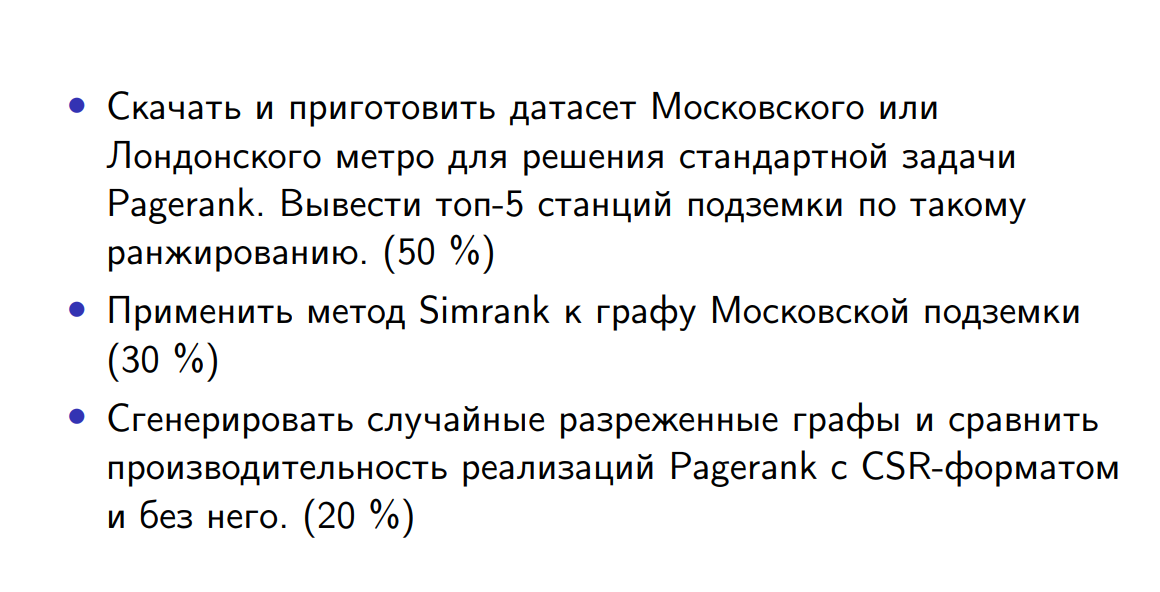

# Датасет Московского метрополитена

In [ ]:
#!/bin/bash
!curl -L -o ~/Downloads/moscow-metro-stations.zip\
  https://www.kaggle.com/api/v1/datasets/download/samoilovmikhail/moscow-metro-stations

# Импорт модулей

In [47]:
import pandas as pd
import networkx as nx
import numpy as np
import warnings
import scipy.sparse as sp

warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)

# Задание 1

## 1. Считаем данные московского метро

In [2]:
metro_lines_df = pd.read_csv(
    "data/moscow_metro/metro_lines.csv", 
    sep=",", 
    encoding="utf-8")

In [3]:
metro_lines_df.sample(4)

,Line,English_name,Russian_name,Stations,Color,First_Opened,Latest_extension,Length,Avg_Dist
2,3,Arbatsko-Pokrovskaya,Арбатско-Покровская,22,#0078BE,1938,2012,45.1,2.15
10,11,Bolshaya Koltsevaya,Большая кольцевая,29,#82C0C0,2018,2023,57.5,1.98
4,5,Koltsevaya,Кольцевая,12,#8D5B2D,1950,1954,19.3,1.61
12,13,Monorail,Монорельс,6,#B9C8E7,2004,2004,4.7,0.94


In [4]:
metro_stations_df = pd.read_csv(
    "data/moscow_metro/metro_stations.csv", 
    sep=",", 
    encoding="utf-8")

In [5]:
metro_stations_df.head(4)

,Station_index,English_name,Line,Russian_name,Depth,Line_Neighbors,Transfers,Opened_Date,Lat,Lon,Station_Type
0,1,Bulvar Rokossovskogo,1,Бульвар Рокоссовского,-8.0,2,266,1990-08-01,55.8147,37.7342,column triple-span
1,2,Cherkizovskaya,1,Черкизовская,-9.0,1 3,267,1990-08-01,55.8039,37.7447,single-vault shallow
2,3,Preobrazhenskaya Ploshchad,1,Преображенская площадь,-8.0,2 4,NaN,1965-12-31,55.7964,37.7150,column triple-span
3,4,Sokolniki,1,Сокольники,-9.0,3 5,221,1935-05-15,55.7889,37.6803,single-vault shallow


## 2. Построим граф метро

In [6]:
# на всякий случай перевожу в стринг
metro_stations_df['Line_Neighbors'] = metro_stations_df['Line_Neighbors'].astype(str)

In [7]:
# Создаем ориентированный граф
G = nx.DiGraph()

In [8]:
# Добавим вершины
for index, row in metro_stations_df.iterrows():
    g_row = row['Station_index']
    g_name = row['Russian_name']
    G.add_node(g_row, name = g_name)

In [9]:
# Добавим ребра по Line_Neighbors (связи по линии)
for index, row in metro_stations_df.iterrows():
    if pd.notna(row["Line_Neighbors"]):
        neighbors = row["Line_Neighbors"].split()
        for n in neighbors:
            G.add_edge(row["Station_index"], int(n))

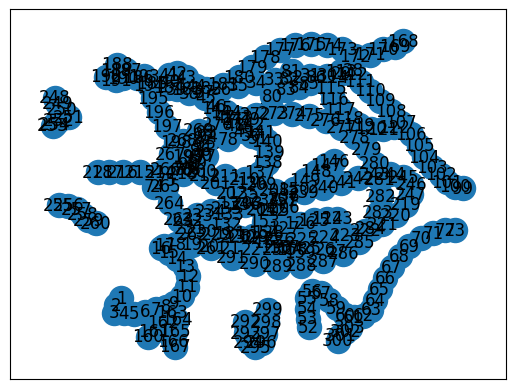

In [10]:
nx.draw_networkx(G)

## 3. Вычислим PageRank

In [11]:
# Вычисляем PageRank
### нужно было предварительно установить scipy
pagerank_scores = nx.pagerank(G)

In [12]:
# Сортируем по убыванию значений PageRank
top = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)

In [13]:
top[0:5]

[(82, 0.004763118181875975),
 (301, 0.004284638990215348),
 (302, 0.004284638990215348),
 (256, 0.003948465328318481),
 (259, 0.003948465328318481)]

## 4. Визуализируем

In [14]:
top_df = pd.DataFrame(top, columns=["Station_index", "Score"])

In [15]:
len(metro_stations_df)

303

In [16]:
res_df = pd.merge(top_df, metro_stations_df, how="left", on="Station_index")

In [17]:
print("Топ-5 станций по PageRank:")
res_df.iloc[0:5]

Топ-5 станций по PageRank:


,Station_index,Score,English_name,Line,Russian_name,Depth,Line_Neighbors,Transfers,Opened_Date,Lat,Lon,Station_Type
0,82,0.004763,Delovoy Tsentr,4,Деловой центр,-25.0,81 83,159,2005-09-10,55.7502,37.5408,column triple-vault
1,301,0.004285,Universitet Druzhby Narodov,16,Университет Дружбы Народов,-23.0,300 302,NaN,2024-09-07,55.6484,37.5076,column triple-span
2,302,0.004285,Generala Tyuleneva,16,Генерала Тюленева,-20.0,301 303,NaN,2024-09-07,55.6262,37.4860,column triple-span
3,256,0.003948,Ulitsa Milashenkova,13,Улица Милашенкова,6.0,255 257,NaN,2004-11-20,55.8218,37.5911,elevated open
4,259,0.003948,Vystavochny Tsentr,13,Выставочный центр,6.0,258 260,NaN,2004-11-20,55.8240,37.6383,elevated open


# Задание 2

In [18]:
# Используем тот же граф 
G

## 1. Измерение сходства

In [19]:
def simrank(G, C=0.8, max_iter=10):
    nodes = list(G.nodes())
    len_nodes = len(nodes)

    s = np.zeros((len_nodes, len_nodes))
    for i in range(len_nodes):
        s[i,i] = 1.0

    node_to_idx = {nodes[i]: i for i in range(len_nodes)}

    for iteration in range(max_iter):
        new_s = np.zeros((len_nodes, len_nodes))
        for i in range(len_nodes):
            for j in range(len_nodes):
                if i==j: new_s[i,j] = 1.0
                else:
                    preds_i = list(G.predecessors(nodes[i]))
                    preds_j = list(G.predecessors(nodes[j]))
                    if len(preds_i) == 0 or len(preds_j) == 0:
                        new_s[i,j] = 0
                    else:
                        sn = 0.0
                        for u in preds_i:
                            for v in preds_j:
                                sn += s[node_to_idx[u], node_to_idx[v]]
                        new_s[i,j] = (C / (len(preds_i)*len(preds_j))) * sn 
        s = new_s
    return s, nodes

In [20]:
%%time
S, nodes = simrank(G, C=0.8, max_iter=10)

CPU times: total: 3.33 s
Wall time: 3.44 s


## 2. Визуализация

In [21]:
rows = []

for target_idx, target_station in enumerate(nodes):
    similarities = []
    for i in range(len(nodes)):
        if i != target_idx:
            similarities.append((nodes[i], S[target_idx, i]))
        similarities.sort(key=lambda x: x[1], reverse=True)

    row = {'Station': metro_stations_df.loc[metro_stations_df['Station_index'] == target_station, 'Russian_name'].values[0]}
    for rank in range(len(nodes)-1):
        station_idx, score = similarities[rank]
        station_name = metro_stations_df.loc[metro_stations_df['Station_index'] == station_idx, 'Russian_name'].values[0]
        row[f"Station_{rank+1}"] = station_name
        row[f"Score_{rank+1}"] = score
    rows.append(row)   

In [22]:
sim_top = pd.DataFrame(rows)

In [23]:
sim_top.columns

Index(['Station', 'Station_1', 'Score_1', 'Station_2', 'Score_2', 'Station_3',
       'Score_3', 'Station_4', 'Score_4', 'Station_5',
       ...
       'Station_298', 'Score_298', 'Station_299', 'Score_299', 'Station_300',
       'Score_300', 'Station_301', 'Score_301', 'Station_302', 'Score_302'],
      dtype='object', length=605)

In [24]:
print("Топ 5 по схожести станций")
sim_top[sim_top.columns[0:11]].sort_values("Score_1", ascending=False).head(5)

Топ 5 по схожести станций


,Station,Station_1,Score_1,Station_2,Score_2,Station_3,Score_3,Station_4,Score_4,Station_5,Score_5
302,Тютчевская,Университет Дружбы Народов,0.666597,Бульвар Рокоссовского,0.000000,Черкизовская,0.0,Преображенская площадь,0.0,Сокольники,0.0
301,Генерала Тюленева,Новаторская,0.666597,Бульвар Рокоссовского,0.000000,Черкизовская,0.0,Преображенская площадь,0.0,Сокольники,0.0
300,Университет Дружбы Народов,Тютчевская,0.666597,Бульвар Рокоссовского,0.000000,Черкизовская,0.0,Преображенская площадь,0.0,Сокольники,0.0
299,Новаторская,Генерала Тюленева,0.666597,Бульвар Рокоссовского,0.000000,Черкизовская,0.0,Преображенская площадь,0.0,Сокольники,0.0
256,Телецентр,Тимирязевская,0.587984,Выставочный центр,0.472541,Бульвар Рокоссовского,0.0,Черкизовская,0.0,Преображенская площадь,0.0


# Задание 2 (с готовым кодом с лекции)

In [111]:
import matplotlib.pyplot as plt

In [112]:
def SimRank(G, C, max_iter=50):
    """
    Compute SimRank similarity measure for graph G.
    :param G: NetworkX graph
    :param C: Coefficient
    :param max_iter: Maximum number of iterations
    :return: Matrix of similarity values
    """
    nodes = list(G.nodes)
    n = len(nodes)
    adj = nx.adjacency_matrix(G).toarray()  # матрица смежности
    adj_normed = adj / np.maximum(np.array([1]), adj.sum(axis=0))   # матрица смежности, нормированная по столбцам
    
    sim = np.eye(n)
    for it in range(max_iter):
        prev_sim = sim.copy()
        matmul = adj_normed.T @ prev_sim @ adj_normed
        sim = C * (matmul - np.diag(matmul.diagonal())) + np.eye(n)
        if np.linalg.norm(sim - prev_sim) < 10e-7:
            print(f'Количество итераций = {it + 1}')
            break
    return sim

def PaintGraph(G, S):
    """
    Convert marix to dictionary for painting graph with similarity values
    :param G: NetworkX graph
    :param S: Matrix of similarity values
    """
    nodes = list(G.nodes)
    similarity = {(nodes[i], nodes[j]): S[i, j] for i in range(len(nodes)) for j in range(len(nodes))}
    # print(similarity)
    pos = nx.circular_layout(G)
    options = {
        'node_color': G.nodes,       # цвет узла
        'node_size': 600,           # размер узла
        'width': 1,                 # ширина линии ребер
        'edge_color':'gray',        # цвет ребра
        'font_color':'black',       # цвет шрифта
    }
    nx.draw(G, pos=pos, with_labels = True, **options)

    # Рисуем метки ребер
    edge_labels = {(u, v): f"{similarity.get((u, v)):.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black')

    plt.title('╰( ͡° ͜ʖ ͡° )──☆*˚ Визуализация графа с SimRank ✧˚')  
    plt.show()

In [119]:
# SimRank
sim_matrix = SimRank(G, C=0.85)

In [120]:
adj = nx.adjacency_matrix(G).toarray()  # матрица смежности
adj_normed = adj / np.maximum(np.array([1]), adj.sum(axis=0))   # матрица смежности, нормированная по столбцам
df = pd.DataFrame(adj, columns=nodes, index=nodes)
print("Матрица связности:")
df

Матрица связности:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

In [121]:
df = pd.DataFrame(sim_matrix, columns=nodes, index=nodes)
print("Матрица сходства SimRank:")
df

Матрица сходства SimRank:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303
1,1.000000,0.000000,0.645758,0.000000,0.326449,0.000000,0.154550,0.000000,0.071038,0.000000,0.032141,0.000000,0.014408,0.000000,0.006420,0.000000,0.002849,0.000000,0.001260,0.000000,0.000558,0.000000,0.000251,0.000000,0.000125,0.000000,0.000091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.00000,0.00000,0.00000
2,0.000000,1.000000,0.000000,0.519431,0.000000,0.248686,0.000000,0.114964,0.000000,0.052187,0.000000,0.023442,0.000000,0.010462,0.000000,0.004648,0.000000,0.002059,0.000000,0.000910,0.000000,0.000405,0.000000,0.000188,0.000000,0.000108,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.00000,0.00000,0.00000
3,0.645758,0.000000,1.000000,0.000000,0.472174,0.000000,0.217116,0.000000,0.098308,0.000000,0.044104,0.000000,0.019673,0.000000,0.00874

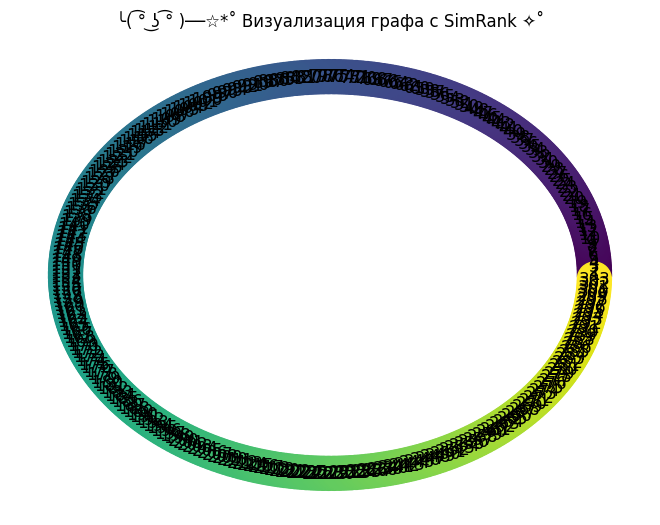

In [122]:
PaintGraph(G, sim_matrix)

👀

# Задание 3

## 1. Генерация случайного разреженного графа.

In [72]:
def generate_dense_graph(n_nodes=1000, avg_degree=10, seed=30):
    X = np.zeros((n_nodes, n_nodes))
    for i in range(n_nodes):
        neighbors = np.random.choice(n_nodes, size=avg_degree, replace=False)
        for j in neighbors:
            X[i, j] = 1
    return X

In [75]:
A_dense = generate_dense_graph(10000, 3, seed=42)

In [76]:
A_dense

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [77]:
G_dense = nx.from_numpy_array(A_dense, create_using=nx.DiGraph)

In [79]:
%%time
pr_res = nx.pagerank(G_dense, alpha=0.85, max_iter=1000, tol=1e-6)

CPU times: total: 62.5 ms
Wall time: 67.8 ms


In [90]:
list(pr_res.items())[0:10]

[(0, 0.00011532498099279834),
 (1, 8.070001867498285e-05),
 (2, 1.9250000000000004e-05),
 (3, 6.897915960005144e-05),
 (4, 8.60823395361797e-05),
 (5, 7.550848018261316e-05),
 (6, 0.00013878252955461248),
 (7, 0.0001767355628450789),
 (8, 4.640302700617284e-05),
 (9, 0.0001844197666366598)]

## 2. Генерация CRS графа

In [91]:
def generate_sparse_graph(n, avg_degree, seed=30):
    p = avg_degree / n
    A = sp.random(n, n, density=p, format="csr", data_rvs=lambda s: np.ones(s))
    col_sum = np.array(A.sum(axis=0)).flatten()
    col_sum[col_sum == 0] = 1
    D = sp.diags(1.0 / col_sum)
    A = A @ D
    return A

In [92]:
B_crs = generate_sparse_graph(10000, 3, seed=42)

In [93]:
G_csr = nx.from_scipy_sparse_array(B_crs, create_using=nx.DiGraph)

In [94]:
%%time
pr_res_csr = nx.pagerank(G_csr, alpha=0.85, max_iter=1000, tol=1e-6)

CPU times: total: 78.1 ms
Wall time: 73.9 ms


In [95]:
list(pr_res_csr.items())[0:10]

[(0, 0.00016819329178278502),
 (1, 6.573298813069729e-05),
 (2, 0.00014344652397271258),
 (3, 8.801942108809533e-05),
 (4, 9.726491718744834e-05),
 (5, 0.0001299195438835371),
 (6, 0.00010340572001432059),
 (7, 7.112994032112473e-05),
 (8, 8.070315115437344e-05),
 (9, 0.00020792314140373006)]